In [10]:
import sys
from pathlib import Path

REPO_ROOT = Path().resolve().parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import *
from analysis.aggregations import *
from analysis.plots import *

## Jupyter notes

## A single run

In [11]:
FOLDER = "26-02-26--11_04_41/mnist-accuracy_only-3-1.0-3-1.0-True-False.pkl"

data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
if FOLDER:
    data_dir = data_dir / FOLDER

run = load_run(data_dir)

# Normalize units: wei → ETH, ratio → %
run = normalize_run(run)
res = merge_runs([run])

### Aggregate global accuracy by round

In [12]:
# data = res['users']
# aggregated = agg_global_accuracy_by_round(data)
#
# aggregated

## Multiple runs

In [13]:
# FOLDER = "26-02-26--11_04_41/"
#
# data_dir = REPO_ROOT / "experiment" / "data" / "experimentData"
# if FOLDER:
#     data_dir = data_dir / FOLDER
#
# runs = load_runs(data_dir)
#
# # Normalize units: wei → ETH, ratio → %
# runs = normalize_runs(runs)
# res = merge_runs(runs)

## Plots

### Plot: plot_accuracy_loss_over_rounds

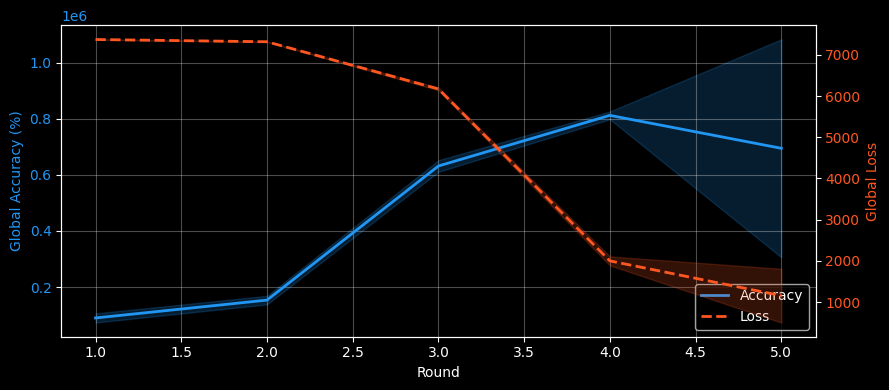

In [14]:
data = res['users']
aggregated = agg_global_accuracy_loss_by_round(data)

fig = plot_accuracy_loss_over_rounds(aggregated) # Assign since it otherwise will plot twice.

### Plot: plot_gas_cost_by_tx_type

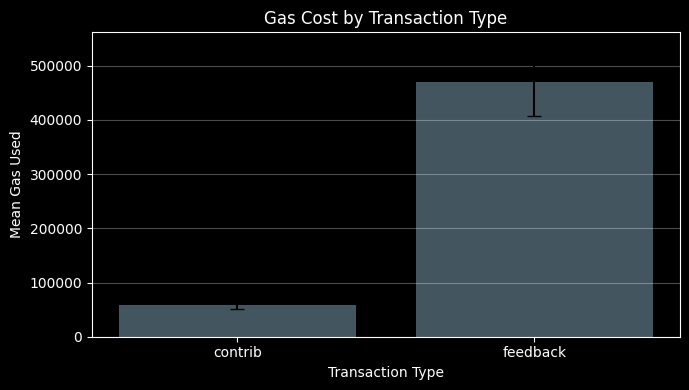

In [15]:
# plot_round_kicked_by_strategy(aggregated)
data = res['receipts']
aggregated = agg_gas_used_by_tx_type(data)
fig = plot_gas_cost_by_tx_type(aggregated)

  ┌──────────────────────────────────────┬──────────────────────────────────┐
  │             Aggregation              │               Plot               │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_global_accuracy_by_round         │ plot_accuracy_loss_over_rounds   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_accuracy_by_strategy             │ plot_strategy_comparison_lines   │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_final_round_accuracy_by_strategy │ plot_strategy_comparison_boxplot │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_grs_by_behavior                  │ plot_grs_by_behavior             │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_gas_used_by_tx_type              │ plot_gas_cost_by_tx_type         │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_round_kicked_by_strategy         │ plot_round_kicked_by_strategy    │
  ├──────────────────────────────────────┼──────────────────────────────────┤
  │ agg_contribution_score_by_behavior   │ (no corresponding plot)          │
  └──────────────────────────────────────┴──────────────────────────────────┘

### Plot: plot_round_kicked_by_strategy

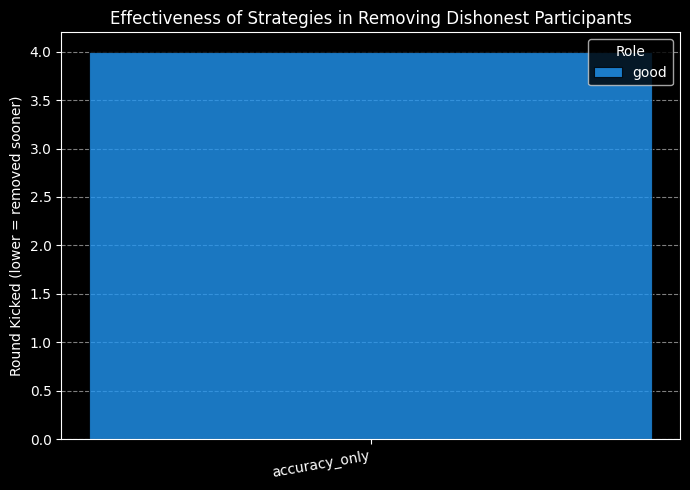

In [16]:
data = res['users']
aggregated = agg_round_kicked_by_strategy(data)
fig = plot_round_kicked_by_strategy(aggregated)

In [17]:
data[data['behavior'] == 'good'].groupby('round')[['accuracy', 'grs']].mean()

# data[data['behavior'] == 'good'] & (data['state'] == 'disqualified')

data[(data['behavior'] == 'good') & (data['state'] == 'disqualified')]


,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
23,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,0,disqualified,good,good,NaN,NaN,0.0,0.8212,...,3,1.0,3,1.0,False,4,1,1,0,5
29,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,0,disqualified,good,good,NaN,NaN,0.0,0.8671,...,3,1.0,3,1.0,False,4,1,1,0,5


In [19]:
data.sort_values('round')


# data = res['votes']
# data[['giver_id', 'giver_address']].drop_duplicates()

data[data['user_id'] == 0]

,experiment_id,round,user_id,state,behavior,role,accuracy,loss,grs,prev_global_accuracy,...,freerider_start_round,freerider_noise_scale,malicious_start_round,malicious_noise_scale,force_merge_all,number_of_good_contributors,number_of_bad_contributors,number_of_freerider_contributors,number_of_inactive_contributors,minimum_rounds
0,mnist-accuracy_only-3-1.0-3-1.0-True-False,1,0,active,good,good,109000.0,7364.0,1.035522,0.0872,...,3,1.0,3,1.0,False,4,1,1,0,5
6,mnist-accuracy_only-3-1.0-3-1.0-True-False,2,0,active,good,good,144000.0,7319.0,1.069525,0.1572,...,3,1.0,3,1.0,False,4,1,1,0,5
12,mnist-accuracy_only-3-1.0-3-1.0-True-False,3,0,active,good,good,620000.0,6179.0,1.253834,0.6381,...,3,1.0,3,1.0,False,4,1,1,0,5
23,mnist-accuracy_only-3-1.0-3-1.0-True-False,4,0,disqualified,good,good,NaN,NaN,0.000000,0.8212,...,3,1.0,3,1.0,False,4,1,1,0,5
29,mnist-accuracy_only-3-1.0-3-1.0-True-False,5,0,disqualified,good,good,NaN,NaN,0.000000,0.8671,...,3,1.0,3,1.0,False,4,1,1,0,5
